In [3]:
import numpy as np
import os

In [18]:
def load_data(path, isImage):

    with open(path, 'rb') as f:
        data = f.read()
        
    num_images = int.from_bytes(data[4:8], 'big')
    rows = int.from_bytes(data[8:12], 'big')
    cols = int.from_bytes(data[12:16], 'big')
    
    if isImage:
        offset = 16  # images have 16-byte header
        arr = np.frombuffer(data, dtype=np.uint8, offset=offset)
        arr = arr.reshape(num_images, rows, cols)
    else:
        offset = 8  # labels have 8-byte header
        arr = np.frombuffer(data, dtype=np.uint8, offset=offset)
        
    return arr

x_train = load_data("../../data/mnist_dataset/train-images-idx3-ubyte", True)
y_train = load_data("../../data/mnist_dataset/train-labels-idx1-ubyte", False)

x_test = load_data("../../data/mnist_dataset/t10k-images-idx3-ubyte", True)
y_test = load_data("../../data/mnist_dataset/t10k-labels-idx1-ubyte", False)

print(x_train.shape)  # (60000, 28, 28)
print(y_train.shape)  # (60000,)
print(x_test.shape)   # (10000, 28, 28)
print(y_test.shape)   # (10000,)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [ ]:


def logistic_regression(model_digit, batch_size=32, learning_rate=0.01, validation_patience=5, epsilon=1e-4, max_epochs=100):
    
    x_train_split, x_val = x_train[:50000], x_train[50000:] # (split, 28, 28)
    x_train_split = x_train_split / 255.0
    x_val = x_val / 255.0

    y_raw_train, y_raw_val = y_train[:50000], y_train[50000:] # (split,)

    y_train_split = (y_raw_train == model_digit).astype(float).reshape(-1, 1) # Extractin only y == model_digit () (split, 1)
    y_val = (y_raw_val == model_digit).astype(float).reshape(-1, 1) # (split, 1)

    x_train_flat = x_train_split.reshape(x_train_split.shape[0], -1) # (split, 784)
    x_train_bias = np.hstack([x_train_flat, np.ones((x_train_split.shape[0], 1))]) # (split, 785)

    x_val_flat = x_val.reshape(x_val.shape[0], -1)  # (split', 784)
    x_val_bias = np.hstack([x_val_flat, np.ones((x_val.shape[0], 1))]) # (split', 785)

    w = np.random.uniform(low=-0.01, high=0.01, size=(785, 1))
    best_v_loss = float('inf')
    patience = validation_patience
    counter = 0
    best_w = None
    
    for epoch in range(max_epochs):
        # shuffle so that every batch contains a representative mix of classes
        indices = np.random.permutation(x_train_split.shape[0])
        x_shuffled = x_train_bias[indices]
        y_shuffled = y_train_split[indices]

        for batch in range(x_train_split.shape[0] // batch_size):
            start = batch * batch_size
            end   = start + batch_size

            xi_batch = x_shuffled[start:end]            # (B, 785)
            z_batch  = np.dot(xi_batch, w)              # (B, 1)
            y_hat    = 1 / (1 + np.exp(-z_batch))       # (B, 1)

            error   = y_hat - y_shuffled[start:end]   # (B, 1)
            de_dw   = np.dot(xi_batch.T, error) / batch_size  # (785, 1)
            w      -= learning_rate * de_dw
            
        z_v = np.dot(x_val_bias, w) #split'x785 * 785x1
        y_hat_v = 1 / (1 + np.exp(-z_v))

        y_hat_v = np.clip(y_hat_v, 1e-15, 1 - 1e-15) # Cap to avoid log(0) errors

        v_loss = -np.mean(y_val * np.log(y_hat_v) + (1 - y_val) * np.log(1 - y_hat_v))

        if v_loss < best_v_loss - epsilon:
            best_v_loss = v_loss
            best_w = w.copy()
            counter = 0
        else:
            counter += 1

        if counter == patience:
            return best_w
        print(f"Epoch: {epoch}, Loss:  {v_loss}")


In [43]:
weights = logistic_regression(6, 1, 0.01, 5, 1e-10, 100)

Epoch: 0, Loss:  0.03837891515440102
Epoch: 1, Loss:  0.038178785700209106
Epoch: 2, Loss:  0.03841934666482093
Epoch: 3, Loss:  0.03457683210479079
Epoch: 4, Loss:  0.03439234981704332
Epoch: 5, Loss:  0.03747862119511291
Epoch: 6, Loss:  0.03584224926784504
Epoch: 7, Loss:  0.036553735369546425
Epoch: 8, Loss:  0.03382558370647812
Epoch: 9, Loss:  0.03486710775642091
Epoch: 10, Loss:  0.03493283053797942
Epoch: 11, Loss:  0.03383629981291962
Epoch: 12, Loss:  0.034595297250168654


In [32]:
def predict(x_test, y_test, model_digit, w):
    # Normalize and flatten
    x_test_flat = x_test.reshape(x_test.shape[0], -1) / 255.0
    x_test_bias = np.hstack([x_test_flat, np.ones((x_test.shape[0], 1))])  # (10000, 785)

    # Forward pass
    z = np.dot(x_test_bias, w)           # (10000, 1)
    y_hat = 1 / (1 + np.exp(-z))         # (10000, 1)

    # Binary labels for this digit
    y_true = (y_test == model_digit).astype(float).reshape(-1, 1)

    # Predictions: threshold at 0.5
    y_pred = (y_hat >= 0.5).astype(float)

    correct = np.sum(y_pred == y_true)
    accuracy = correct / len(y_true) * 100

    true_positives  = np.sum((y_pred == 1) & (y_true == 1))
    false_positives = np.sum((y_pred == 1) & (y_true == 0))
    false_negatives = np.sum((y_pred == 0) & (y_true == 1))

    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall    = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"Results for digit {model_digit}:")
    print(f"  Accuracy:  {accuracy:.2f}%")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")


predict(x_test, y_test, 7, weights)


Results for digit 7:
  Accuracy:  98.47%
  Precision: 0.9362
  Recall:    0.9134
  F1 Score:  0.9247


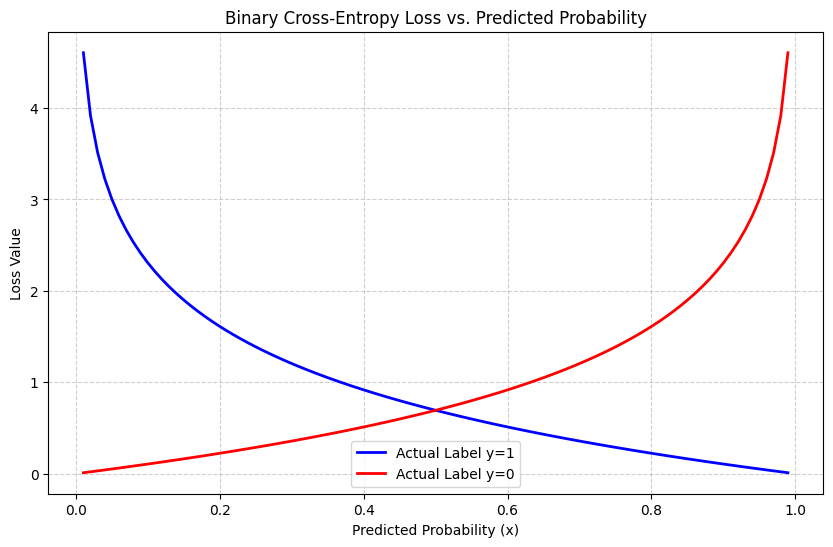

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0.01, 0.99, 100)

loss_y1 = -np.log(x)           
loss_y0 = -np.log(1 - x)      

# 3. Plotting
plt.figure(figsize=(10, 6))

plt.plot(x, loss_y1, label='Actual Label y=1', color='blue', lw=2)
plt.plot(x, loss_y0, label='Actual Label y=0', color='red', lw=2)

plt.title('Binary Cross-Entropy Loss vs. Predicted Probability')
plt.xlabel('Predicted Probability (x)')
plt.ylabel('Loss Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

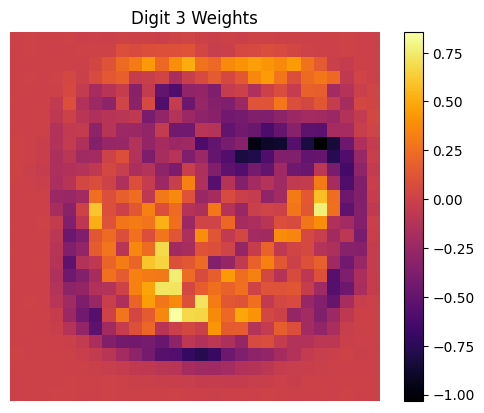

In [44]:
import matplotlib.pyplot as plt

def visualize_weights(w, title="Weight Visualization"):
    # Remove bias term
    w_no_bias = w[:-1]  # (784,)

    # Reshape into 28x28 image
    img = w_no_bias.reshape(28, 28)

    # Plot
    plt.figure()
    plt.imshow(img, cmap='inferno')  # orange heatmap style
    plt.colorbar()
    plt.title(title)
    plt.axis('off')
    plt.show()
    
digit = 3
visualize_weights(weights, title=f"Digit {digit} Weights")